In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('NSE All Share Historical Data (2).csv')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,22/12/2023,"74,023.27","74,288.88","74,430.47","73,993.49",423.20M,-0.36%
1,21/12/2023,"74,289.02","73,397.71","74,292.76","73,397.71",760.93M,1.21%
2,20/12/2023,"73,397.71","72,470.10","73,399.61","72,470.10",552.22M,1.28%
3,19/12/2023,"72,470.10","72,404.91","72,489.21","72,320.32",411.06M,0.09%
4,18/12/2023,"72,404.91","72,389.23","72,413.13","72,276.75",324.15M,0.02%


In [2]:
print(df.columns.tolist())

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


In [3]:
df.shape

(2948, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2948 entries, 0 to 2947
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2948 non-null   object
 1   Price     2948 non-null   object
 2   Open      2948 non-null   object
 3   High      2948 non-null   object
 4   Low       2948 non-null   object
 5   Vol.      1651 non-null   object
 6   Change %  2948 non-null   object
dtypes: object(7)
memory usage: 161.3+ KB


In [5]:
##  Checking for missing values

df.isnull().sum()

Date           0
Price          0
Open           0
High           0
Low            0
Vol.        1297
Change %       0
dtype: int64

In [6]:
##  Checking basic statistics

df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,2948,2948,2948,2948,2948,1651,2948
unique,2948,2939,2938,2932,2938,1614,501
top,22/12/2023,"26,609.34","20,658.28","37,259.65","37,278.34",1.06B,0.02%
freq,1,2,3,4,3,3,35


In [7]:
## Cleaning the data

In [12]:
## Converting the  Date to proper format

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df['Date'].head())

0   2023-12-22
1   2023-12-21
2   2023-12-20
3   2023-12-19
4   2023-12-18
Name: Date, dtype: datetime64[ns]


In [14]:
##  Clean Change % column

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)
print(df['Change %'].head())

0   -0.36
1    1.21
2    1.28
3    0.09
4    0.02
Name: Change %, dtype: float64


In [15]:
##  Drop the missing Volume rows

df = df.dropna(subset=['Vol.'])
print(df.shape)

(1651, 7)


In [16]:
##  Confirm everything is clean

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 2042
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1651 non-null   datetime64[ns]
 1   Price     1651 non-null   float64       
 2   Open      1651 non-null   float64       
 3   High      1651 non-null   float64       
 4   Low       1651 non-null   float64       
 5   Vol.      1651 non-null   object        
 6   Change %  1651 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 103.2+ KB
None


In [17]:
def convert_volume(val):
    if pd.isna(val):
        return 0
    val = str(val).replace(',', '')
    if 'B' in val:
        return float(val.replace('B', '')) * 1000000000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1000000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1000
    else:
        return float(val)

df['Vol.'] = df['Vol.'].apply(convert_volume)
print(df['Vol.'].head())

0    423200000.0
1    760930000.0
2    552220000.0
3    411060000.0
4    324150000.0
Name: Vol., dtype: float64


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 2042
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1651 non-null   datetime64[ns]
 1   Price     1651 non-null   float64       
 2   Open      1651 non-null   float64       
 3   High      1651 non-null   float64       
 4   Low       1651 non-null   float64       
 5   Vol.      1651 non-null   float64       
 6   Change %  1651 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 103.2 KB
None


In [19]:
## Now let us analyze the data

In [20]:
print(df.describe())

                                Date         Price          Open  \
count                           1651   1651.000000   1651.000000   
mean   2020-06-09 23:04:10.757117184  39371.897644  39338.234506   
min              2015-09-23 00:00:00  20669.380000  20683.160000   
25%              2018-05-02 12:00:00  27736.930000  27721.830000   
50%              2020-08-26 00:00:00  38522.140000  38507.290000   
75%              2022-04-25 12:00:00  47220.590000  47206.150000   
max              2023-12-22 00:00:00  74289.020000  74288.880000   
std                              NaN  12242.980742  12215.179826   

               High           Low          Vol.     Change %  
count   1651.000000   1651.000000  1.651000e+03  1651.000000  
mean   39503.858552  39185.495669  3.419977e+08     0.067929  
min    20925.190000  20651.590000  5.188000e+07    -4.910000  
25%    27863.030000  27612.485000  1.925800e+08    -0.290000  
50%    38624.530000  38395.370000  2.669500e+08     0.020000  
75%    47

In [21]:
##  Highest price ever recorded

highest_price = df.loc[df['Price'].idxmax()]
print(highest_price)

Date        2023-12-21 00:00:00
Price                  74289.02
Open                   73397.71
High                   74292.76
Low                    73397.71
Vol.                760930000.0
Change %                   1.21
Name: 1, dtype: object


In [22]:
##  Lowest price ever recorded

lowest_price = df.loc[df['Price'].idxmin()]
print(lowest_price)

Date        2020-04-06 00:00:00
Price                  20669.38
Open                   21094.62
High                   21208.95
Low                    20651.59
Vol.                336420000.0
Change %                  -2.02
Name: 920, dtype: object


In [23]:
##   Average closing price

print(f"Average Closing Price: {df['Price'].mean():,.2f}")

Average Closing Price: 39,371.90


In [24]:
##  Best performing day

best_day = df.loc[df['Change %'].idxmax()]
print(best_day)

Date        2020-11-12 00:00:00
Price                  35342.46
Open                   33291.27
High                   35342.46
Low                    33291.27
Vol.               1190000000.0
Change %                   6.23
Name: 772, dtype: object


In [25]:
##  Worst performing day

worst_day = df.loc[df['Change %'].idxmin()]
print(worst_day)

Date        2020-03-10 00:00:00
Price                  24388.66
Open                   25412.57
High                   25412.57
Low                    24381.88
Vol.                594470000.0
Change %                  -4.91
Name: 939, dtype: object


In [26]:
##  Average daily trading volume

print(f"Average Daily Volume: {df['Vol.'].mean():,.0f}")

Average Daily Volume: 341,997,686


In [27]:
## Visualization

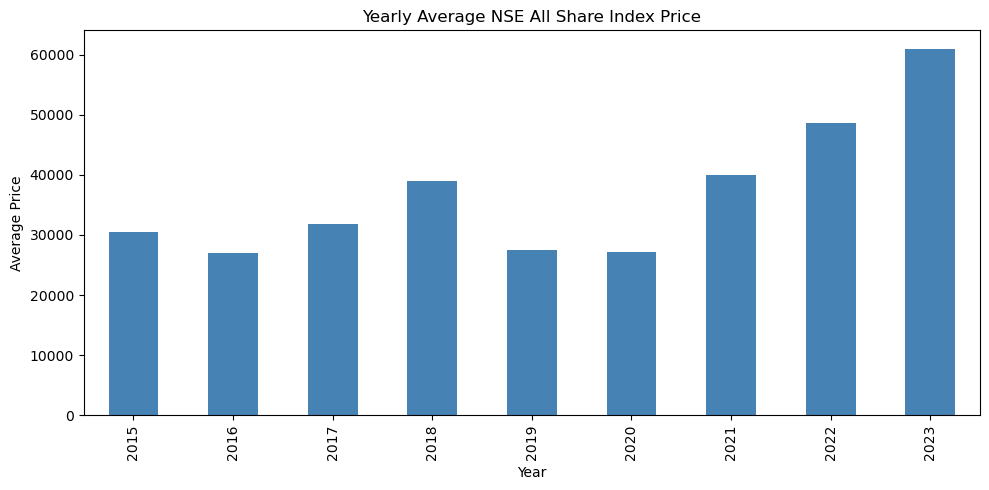

In [28]:
##   Price trend over time (Line Chart)

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot(kind='bar', color='steelblue')
plt.title('Yearly Average NSE All Share Index Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

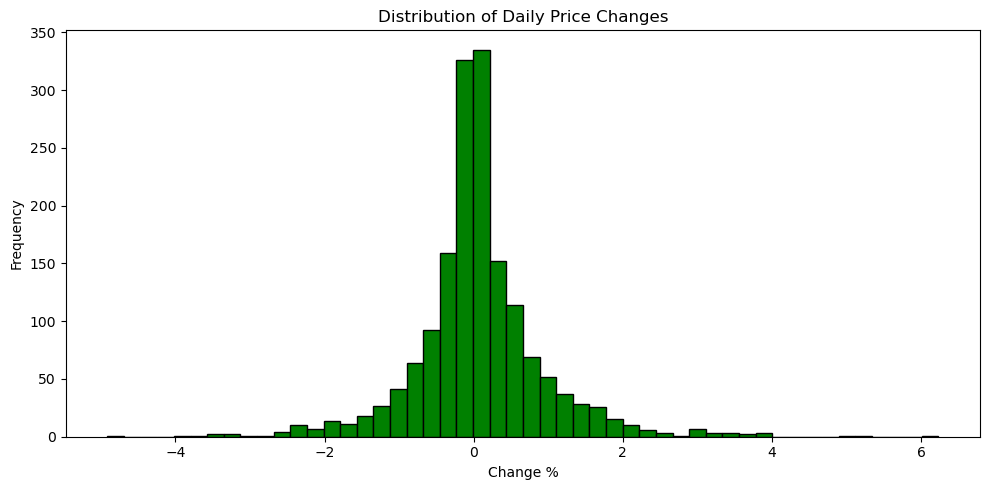

In [29]:
##   Daily Change % Distribution (Histogram)

plt.figure(figsize=(10,5))
plt.hist(df['Change %'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Daily Price Changes')
plt.xlabel('Change %')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

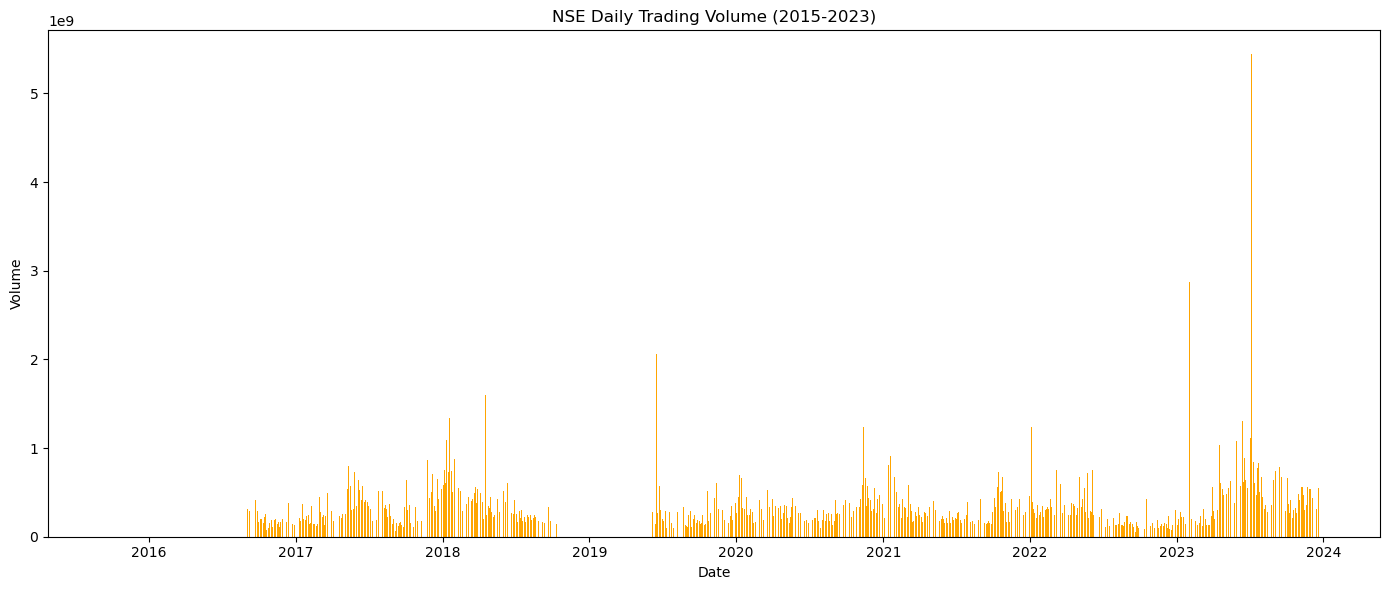

In [30]:
##   Trading Volume over time (Bar Chart)

plt.figure(figsize=(14,6))
plt.bar(df['Date'], df['Vol.'], color='orange')
plt.title('NSE Daily Trading Volume (2015-2023)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

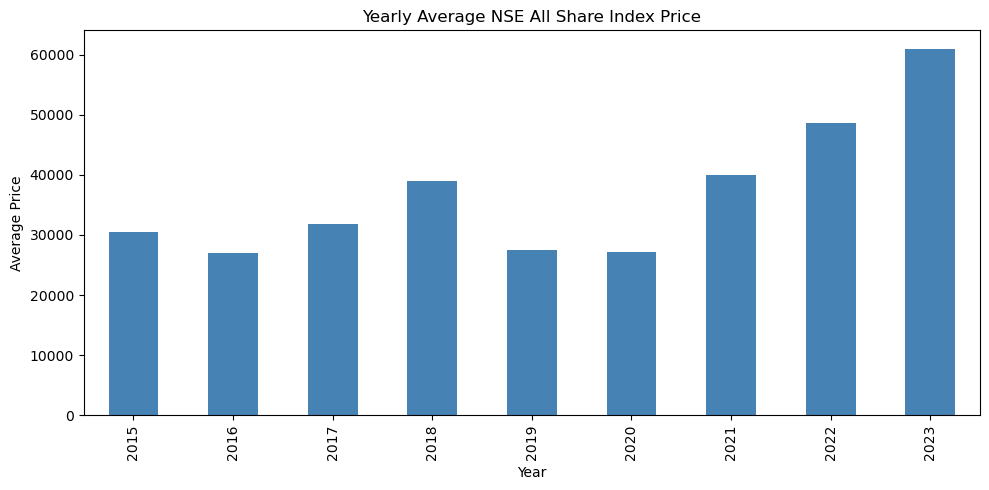

In [31]:
## Yearly average price (Bar Chart)

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot(kind='bar', color='steelblue')
plt.title('Yearly Average NSE All Share Index Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

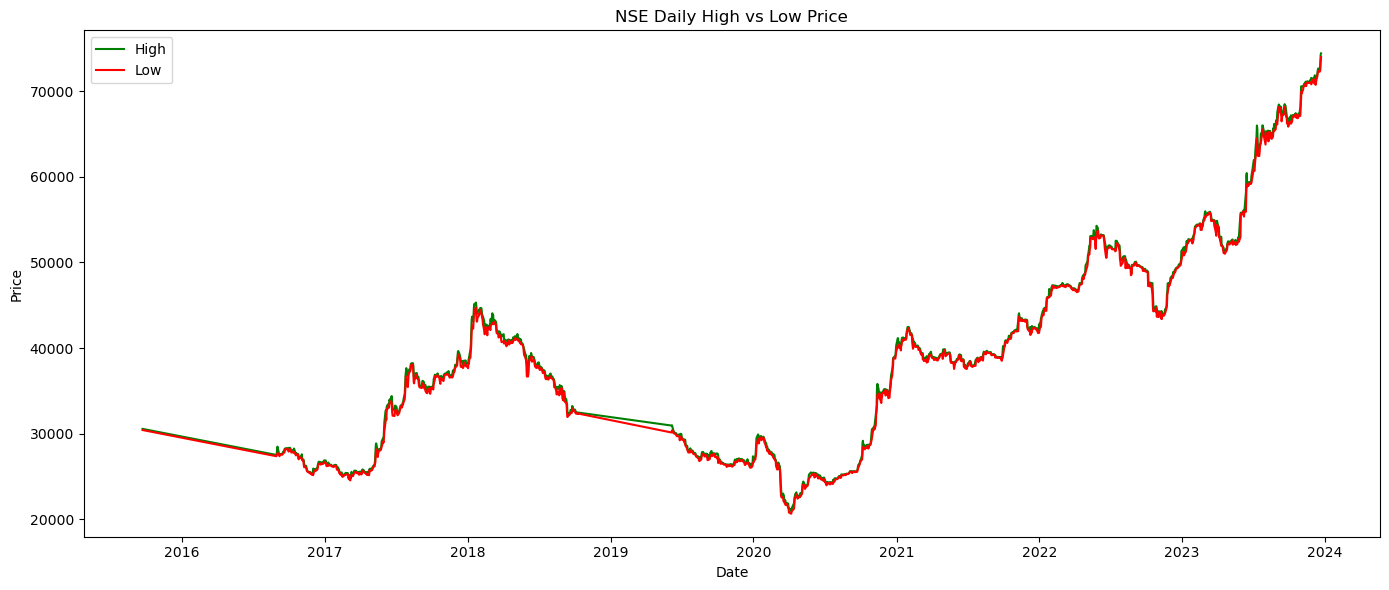

In [32]:
## High vs Low price over time

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['High'], color='green', label='High')
plt.plot(df['Date'], df['Low'], color='red', label='Low')
plt.title('NSE Daily High vs Low Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
df.to_csv('nse_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
